# Test Performance Controller (overfitting diagnostic)

Evaluates the trained PF controller with the **same tail-NLL loss used during training**, comparing:

- **dev** units with a leave-one-unit-out prior (the *seen* distribution, matching the training evaluation), and
- **test** units with the full dev prior (the *unseen* deployment scenario).

A large `test - dev` gap indicates overfitting. No video is generated. Uses hyperparameter set `ARGS_ID` from `PFNET_ARGS`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from experiment_config import (
    SEED,
    DegModel,
    count_baseline_trials,
    dataset_paths,
    load_baseline_gains,
    pfnet_paths,
)
from src.helpers.seed import set_global_seed
from src.models.networks.pf_mlp import ParticleFilterMLP, build_activation
from src.models.particle_filter.core import ParticleFilter
from src.training.pfnet_hparams import PFNET_ARGS


## Configuration

In [2]:
DATA_NAME = "DS01"
ARGS_ID = 0

## Parameters

In [3]:
ESTIMATION_DIR, DEGR_MODEL_DIR = dataset_paths(
    DATA_NAME, fields=["estimation", "degr_model"]
)
args = PFNET_ARGS[ARGS_ID]
net_args = args["NETWORK"]
USE_NET = net_args is not None  # net_args None -> no-network PF baseline
pf_args = args["PARTICLE_FILTER"]
train_args = args["TRAINING"]
eval_args = args["EVALUATION"]

LOSS_TAIL_STEPS = int(train_args["LOSS_TAIL_STEPS"])
EVAL_REPS = int(eval_args["REPETITIONS"])
SEED_STRIDE = int(eval_args["SEED_STRIDE"])

PFNET_ARGS_DIR, _ = pfnet_paths(ARGS_ID, DATA_NAME)
PFNET_ARGS_DIR.mkdir(parents=True, exist_ok=True)


set_global_seed(SEED)

## Load data

In [4]:
dev_hi = pd.read_csv(ESTIMATION_DIR / "data_dev.csv")
test_hi = pd.read_csv(ESTIMATION_DIR / "data_test.csv")

dev_units = sorted(dev_hi["unit"].astype(int).unique().tolist())
test_units = sorted(test_hi["unit"].astype(int).unique().tolist())
perform_names = [c for c in dev_hi.columns if c not in ["unit", "cycle", "hs"]]

print("dev units:", dev_units)
print("test units:", test_units)
print("performance metrics:", perform_names)

dev units: [1, 2, 4, 5, 6]
test units: [7, 8, 9, 10]
performance metrics: ['T48', 'SmFan', 'SmLPC', 'SmHPC']


In [5]:
def build_tensors(df, units, name):
    tensors = {}
    for unit in units:
        sub = df[df["unit"] == unit]
        t = sub["cycle"].values
        s = sub[name].values
        tensors[unit] = torch.tensor(np.stack([t, s], axis=1), dtype=torch.float32)
    return tensors

## Tail-NLL (same metric as training)

For each step the PF is advanced one observation, then the negative log-likelihood of the
true time-to-failure is averaged over the last `LOSS_TAIL_STEPS` states. Evaluation is
repeated with fixed per-unit seeds (isolated via `fork_rng`) so only the learned weights
affect the result.

In [6]:
def tail_nll(pf, t_data, s_data):
    step_losses = []
    for k in range(len(t_data)):
        mixture = pf.step(t_obs=t_data[[k]], s_obs=s_data[[k]])
        start = -LOSS_TAIL_STEPS if LOSS_TAIL_STEPS else k
        dist = mixture.distribution(s=s_data[start:])
        step_losses.append(-dist.log_prob(t_data[start:]).mean())
    return float(torch.stack(step_losses).mean().item())


def eval_unit(base_models, net, unit_tensor, seeds, gains=None):
    # gains only used for the no-network baseline; ignored when use_net=True
    gains = gains or {"NOISE": None, "PRIOR": None, "LIK": None}
    t_data = unit_tensor[:, 0]
    s_data = unit_tensor[:, 1]
    rep_losses = []
    for eval_seed in seeds:
        with torch.random.fork_rng(devices=[]):
            torch.manual_seed(eval_seed)
            pf = ParticleFilter(
                base_models=base_models,
                net=net,
                n_particles=int(pf_args["N_PARTICLES"]),
                max_life=int(pf_args["MAX_LIFE"]),
                use_net=USE_NET,
                const_noise=gains["NOISE"],
                const_prior=gains["PRIOR"],
                const_lik=gains["LIK"],
            ).eval()
            rep_losses.append(tail_nll(pf, t_data, s_data))
    return float(np.mean(rep_losses))


## Evaluate dev vs test

In [7]:
records = []
for perform_name in perform_names:
    # trained controller for this metric (args0 baseline has no checkpoint)
    if USE_NET:
        net = ParticleFilterMLP(
            state_dim=DegModel.state_dim(),
            hidden_dims=list(net_args["HIDDEN_DIMS"]),
            activation=build_activation(net_args),
            dropout_p=float(net_args["DROPOUT"]),
        )
        ckpt = torch.load(
            PFNET_ARGS_DIR / perform_name / "checkpoint_best.pt", weights_only=False
        )
        # last checkpoint tells how many epochs were actually trained
        last_ckpt = torch.load(
            PFNET_ARGS_DIR / perform_name / "checkpoint_last.pt", weights_only=False
        )
        total_epochs = int(last_ckpt.get("epoch", -1)) + 1
        best_score_val = float(ckpt.get("best_score", np.nan))
        best_epoch_val = int(ckpt.get("epoch", -1))
        net.load_state_dict(ckpt["model_state"])
        net = net.eval()
    else:
        net = None
        total_epochs = 0
        best_score_val = float("nan")
        best_epoch_val = -1

    # baseline only (net is None): per-metric constant gains + Optuna trial count
    metric_gains = (
        load_baseline_gains(ARGS_ID, DATA_NAME, perform_name) if net is None else None
    )
    n_trials = (
        count_baseline_trials(ARGS_ID, DATA_NAME, perform_name) if net is None else 0
    )

    # base degradation-model population (from dev units)
    dev_degmodels = {}
    for unit in dev_units:
        model = DegModel()
        model.load_state_dict(
            torch.load(
                DEGR_MODEL_DIR
                / "states"
                / perform_name
                / f"unit_{unit}"
                / "best_model.pt"
            )
        )
        dev_degmodels[unit] = model

    dev_tensors = build_tensors(dev_hi, dev_units, perform_name)
    test_tensors = build_tensors(test_hi, test_units, perform_name)

    # dev: leave-one-unit-out prior (matches training evaluation)
    dev_losses = []
    for unit in dev_units:
        base = [dev_degmodels[u] for u in dev_units if u != unit]
        seeds = [SEED + unit * SEED_STRIDE + rep for rep in range(EVAL_REPS)]
        dev_losses.append(eval_unit(base, net, dev_tensors[unit], seeds, metric_gains))

    # test: full dev prior (deployment scenario)
    full_base = [dev_degmodels[u] for u in dev_units]
    test_losses = []
    for unit in test_units:
        seeds = [SEED + unit * SEED_STRIDE + rep for rep in range(EVAL_REPS)]
        test_losses.append(
            eval_unit(full_base, net, test_tensors[unit], seeds, metric_gains)
        )

    dev_nll = float(np.mean(dev_losses))
    test_nll = float(np.mean(test_losses))
    records.append(
        {
            "perform": perform_name,
            "dev_nll": dev_nll,
            "test_nll": test_nll,
            "gap": test_nll - dev_nll,
            "ckpt_best_score": best_score_val,
            "best_epoch": best_epoch_val,
            "total_epochs": total_epochs,
            "n_trials": n_trials,
        }
    )
    # baseline reports Optuna trials; a trained network reports epochs
    fit_info = (
        f"trials={n_trials}"
        if net is None
        else f"best={best_epoch_val} total={total_epochs}"
    )
    print(
        f"{perform_name}: dev={dev_nll:.4f} test={test_nll:.4f} "
        f"gap={test_nll - dev_nll:+.4f} || {fit_info}"
    )


results = pd.DataFrame(records).set_index("perform")
results


T48: dev=3.2030 test=3.4685 gap=+0.2655 || trials=160
SmFan: dev=3.4892 test=4.7038 gap=+1.2146 || trials=169
SmLPC: dev=3.2960 test=3.4337 gap=+0.1377 || trials=159
SmHPC: dev=3.3131 test=3.3567 gap=+0.0436 || trials=154


,dev_nll,test_nll,gap,ckpt_best_score,best_epoch,total_epochs,n_trials
perform,,,,,,,
T48,3.202996,3.468462,0.265465,NaN,-1,0,160
SmFan,3.489171,4.703793,1.214622,NaN,-1,0,169
SmLPC,3.295992,3.433688,0.137695,NaN,-1,0,159
SmHPC,3.313076,3.356668,0.043591,NaN,-1,0,154


## Summary plot

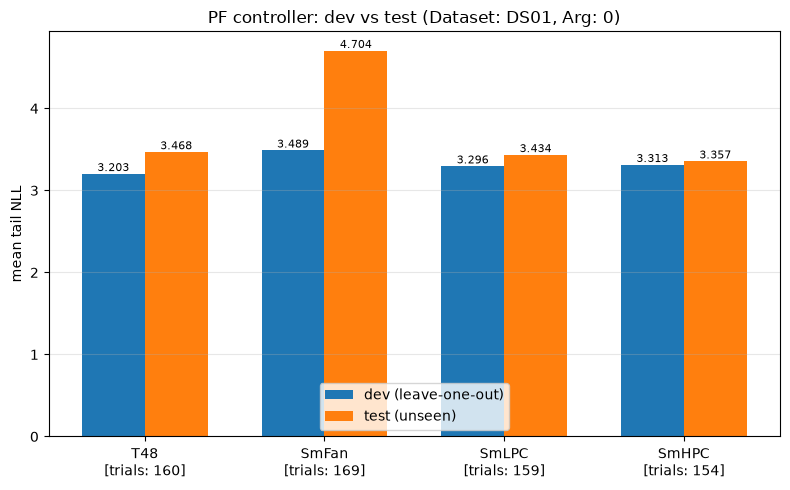

Saved /lustre/diazgonz/deep-performance-rul/experiments/DS01/opcond_q0.001-0.999_corr0.6_range0.6/estimation_thr0.2/gamma/net_arg0/test_performance_dev_vs_test.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results))
width = 0.35


bars1 = ax.bar(x - width / 2, results["dev_nll"], width, label="dev (leave-one-out)")
bars2 = ax.bar(x + width / 2, results["test_nll"], width, label="test (unseen)")

for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
ax.set_xticks(x)
# baseline (args0) reports Optuna trials; a trained network reports epochs
_count_col = "total_epochs" if USE_NET else "n_trials"
_count_label = "train" if USE_NET else "trials"
xtick_labels = [
    f"{name}\n[{_count_label}: {n}]"
    for name, n in zip(results.index, results[_count_col])
]
ax.set_xticklabels(xtick_labels)
ax.set_ylabel("mean tail NLL")
ax.set_title(f"PF controller: dev vs test (Dataset: {DATA_NAME}, Arg: {ARGS_ID})")
ax.legend(loc="lower center")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

out_path = PFNET_ARGS_DIR / "test_performance_dev_vs_test.png"
fig.savefig(out_path, dpi=200)
results.to_csv(PFNET_ARGS_DIR / "test_performance_dev_vs_test.csv")
plt.show()
print(f"Saved {out_path}")


## DS01

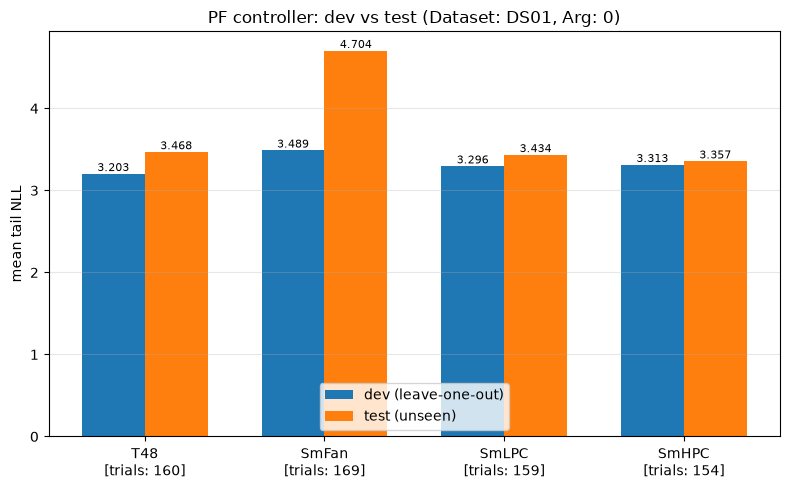
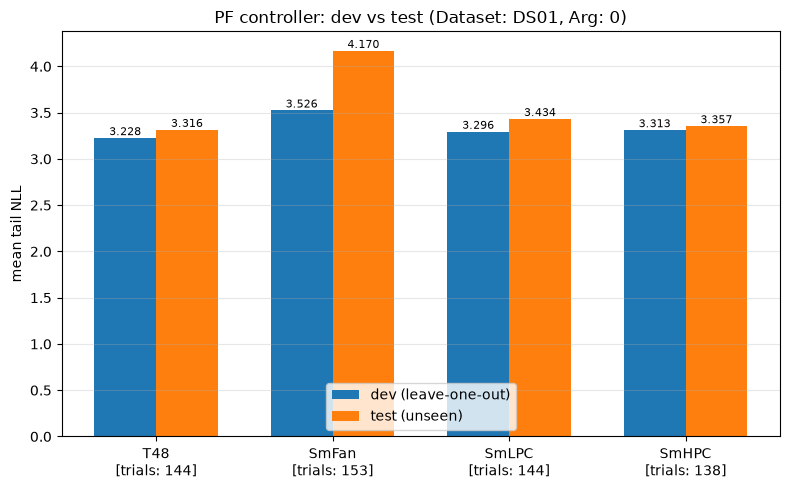

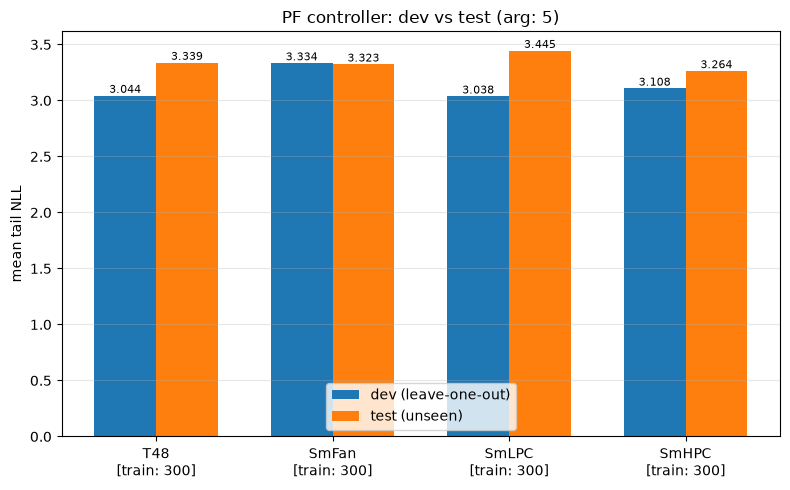

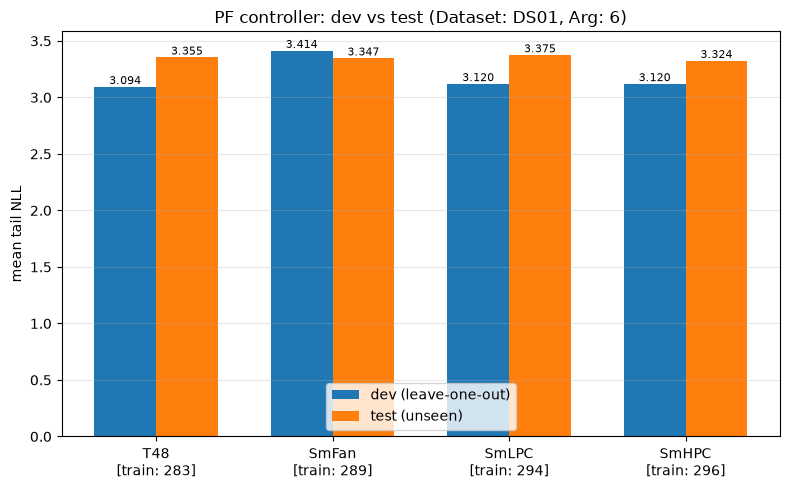

## DS03

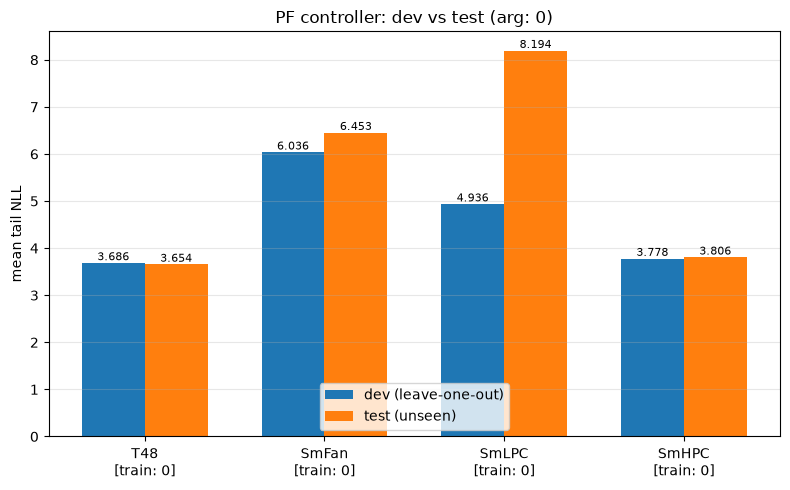

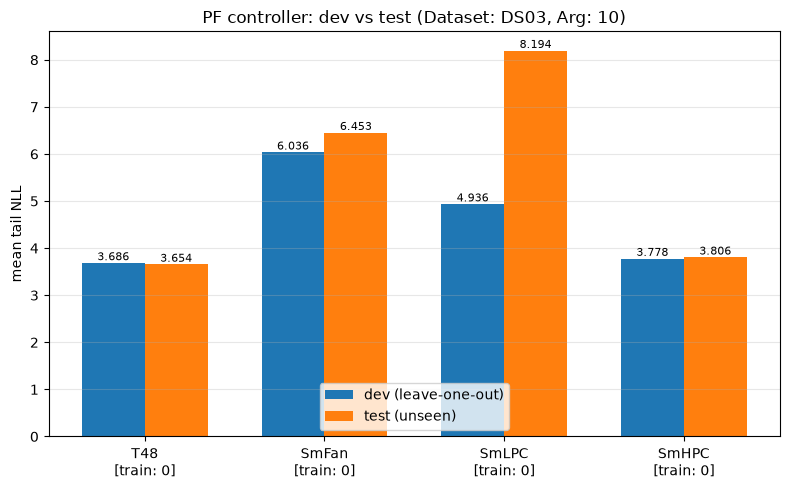

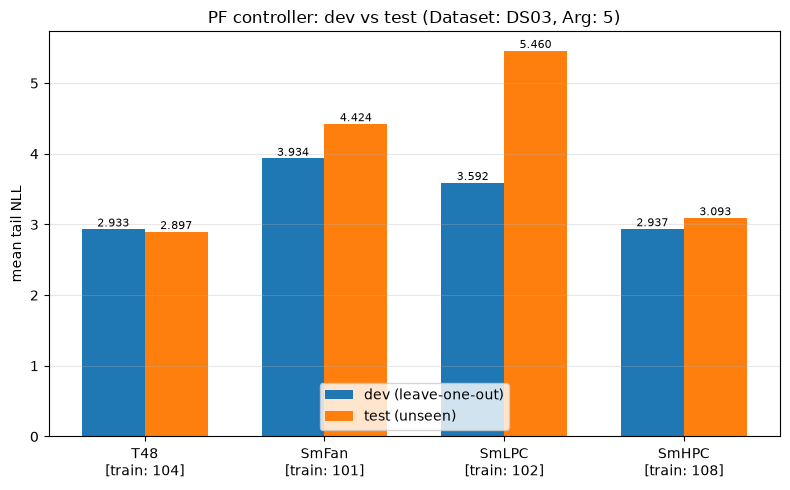

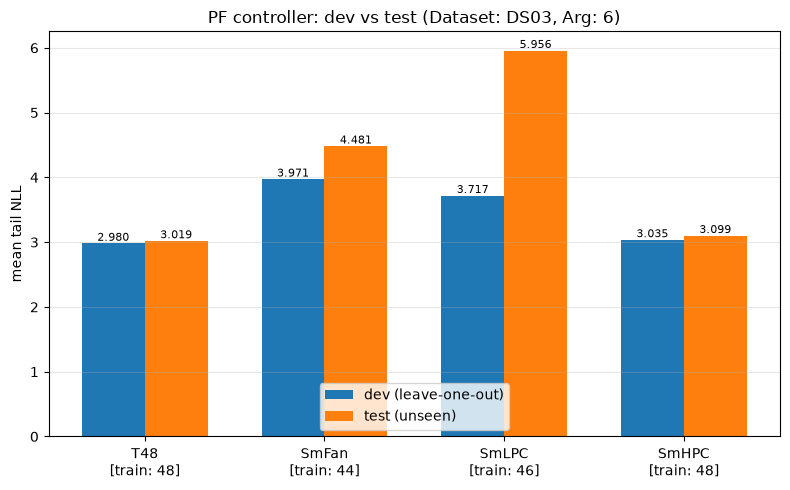

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 